# Q3 — Cumulative Distribution Function Analysis

**Question 3**: Create separate CDFs of PM2.5 and WBGT overall, by time of day, and per site.

**Date**: April 4, 2026

## Dashboard & Layout Recommendations (for Design Team)

<details>
<summary>Click to view AI recommendations</summary>

### Key Performance Indicators
- **PM2.5 NAAQS Exceedance**: % of readings above 9.0 µg/m³ (annual standard) and 35.0 µg/m³ (24-hour standard)
- **WBGT Heat Risk Distribution**: % of time above OSHA thresholds (80°F Caution, 85°F Warning, 90°F Danger)
- **Day-Night Distribution Differences**: Kolmogorov-Smirnov test statistics and p-values for temporal patterns
- **Site Variability Index**: Range between P90 values across sites to quantify spatial heterogeneity

### Visualization Recommendations
1. **Interactive CDF Plot**: Side-by-side PM2.5 and WBGT with toggleable site overlays
2. **Heat Map Matrix**: Sites × Time periods showing median concentrations
3. **Risk Distribution Pie Charts**: Proportion of time in each OSHA/EPA risk category
4. **Small Multiples**: Grid of site-specific CDFs for detailed comparison

### Dashboard Layout
- **Header (10%)**: KPI cards showing key exceedance percentages
- **Main Panel (60%)**: Large interactive CDF plots with regulatory thresholds
- **Side Panel (30%)**: Site comparison matrix and temporal breakdowns
- **Color Scheme**: Cool blues for PM2.5, warm reds for WBGT, categorical palette for sites

</details>

In [1]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
})

# Colors
PM_COLOR = "#4C72B0"
WBGT_COLOR = "#C44E52"
DAY_COLOR = "#4C72B0"
NIGHT_COLOR = "#DD8452"

# Site name mapping
SITE_NAMES = {
    "berkley": "Berkeley Garden", "castle": "Castle Square", "chin": "Chin Park",
    "dewey": "Dewey Square", "eliotnorton": "Eliot Norton Park", "greenway": "One Greenway",
    "lyndenboro": "Lyndboro Park", "msh": "Mary Soo Hoo Park", "oxford": "Oxford Place",
    "reggie": "Reggie Wong Park", "taitung": "Tai Tung Park", "tufts": "Tufts Community Garden"
}

# Load data
df = pd.read_parquet("../../data/clean/data_HEROS_clean.parquet")

print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Sites: {df['site_id'].nunique()} — {sorted(df['site_id'].unique())}")

Dataset: 48,123 rows × 46 columns
Date range: 2023-07-19 16:40:00 to 2023-08-23 15:50:00
Sites: 12 — ['berkley', 'castle', 'chin', 'dewey', 'eliotnorton', 'greenway', 'lyndenboro', 'msh', 'oxford', 'reggie', 'taitung', 'tufts']


## KPI Overview

The key metrics that answer the CDF question at a glance:

In [2]:
# Key columns
pm_col = "pa_mean_pm2_5_atm_b_corr_2"
wbgt_col = "kes_mean_wbgt_f"

# Calculate KPIs
pm_data = df[pm_col].dropna()
wbgt_data = df[wbgt_col].dropna()

kpis = {
    "PM2.5 Observations": f"{len(pm_data):,}",
    "PM2.5 Mean (µg/m³)": f"{pm_data.mean():.2f}",
    "PM2.5 > 9.0 µg/m³ (NAAQS Annual)": f"{(pm_data > 9.0).mean()*100:.1f}%",
    "PM2.5 > 35.0 µg/m³ (NAAQS 24-hr)": f"{(pm_data > 35.0).mean()*100:.2f}%",
    "WBGT Observations": f"{len(wbgt_data):,}",
    "WBGT Mean (°F)": f"{wbgt_data.mean():.2f}",
    "WBGT > 80°F (OSHA Caution)": f"{(wbgt_data > 80).mean()*100:.1f}%",
    "WBGT > 85°F (OSHA Warning)": f"{(wbgt_data > 85).mean()*100:.1f}%",
    "WBGT > 90°F (OSHA Danger)": f"{(wbgt_data > 90).mean()*100:.1f}%"
}

# Display as formatted table
print("CHINATOWN HEROS — Q3 CDF ANALYSIS KEY METRICS")
print("=" * 70)
for metric, value in kpis.items():
    print(f"{metric:<40} {value:>15}")
print("=" * 70)

CHINATOWN HEROS — Q3 CDF ANALYSIS KEY METRICS
PM2.5 Observations                                47,009
PM2.5 Mean (µg/m³)                                  9.49
PM2.5 > 9.0 µg/m³ (NAAQS Annual)                   46.3%
PM2.5 > 35.0 µg/m³ (NAAQS 24-hr)                   0.00%
WBGT Observations                                 46,404
WBGT Mean (°F)                                     65.86
WBGT > 80°F (OSHA Caution)                          0.0%
WBGT > 85°F (OSHA Warning)                          0.0%
WBGT > 90°F (OSHA Danger)                           0.0%


## Foundational EDA

Basic distributions and summary statistics to orient our CDF analysis:


=== PM2.5 DISTRIBUTION SUMMARY ===
count    47009.000000
mean         9.487614
std          5.338261
min          0.880447
25%          5.123096
50%          8.326800
75%         13.425973
max         25.086852
Name: pa_mean_pm2_5_atm_b_corr_2, dtype: float64
Skewness: 0.648
Kurtosis: -0.366

=== WBGT DISTRIBUTION SUMMARY ===
count    46404.000000
mean        65.856196
std          4.822856
min         54.800000
25%         62.600000
50%         66.200000
75%         68.900000
max         77.500000
Name: kes_mean_wbgt_f, dtype: float64
Skewness: -0.047
Kurtosis: -0.434


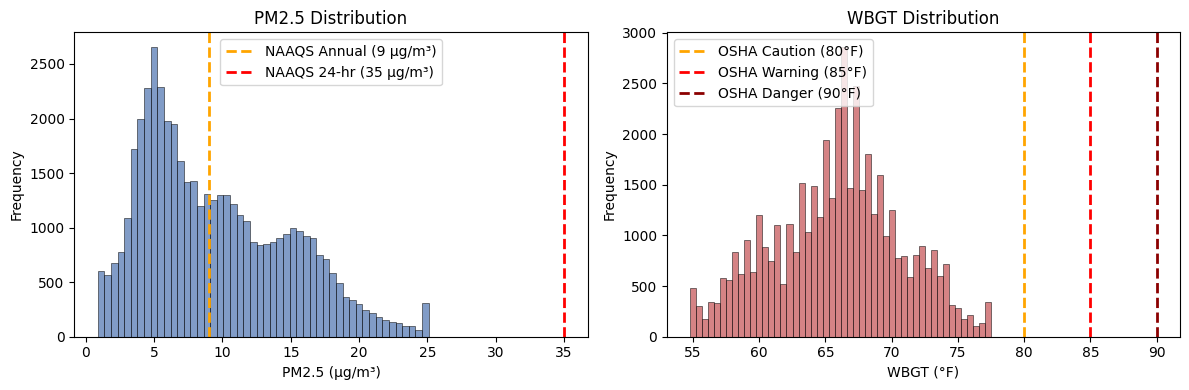

In [3]:
# Summary statistics for both variables
print("\n=== PM2.5 DISTRIBUTION SUMMARY ===")
print(pm_data.describe())
print(f"Skewness: {pm_data.skew():.3f}")
print(f"Kurtosis: {pm_data.kurtosis():.3f}")

print("\n=== WBGT DISTRIBUTION SUMMARY ===")
print(wbgt_data.describe())
print(f"Skewness: {wbgt_data.skew():.3f}")
print(f"Kurtosis: {wbgt_data.kurtosis():.3f}")

# Basic histograms for context
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PM2.5 histogram
axes[0].hist(pm_data, bins=50, alpha=0.7, color=PM_COLOR, edgecolor='black', linewidth=0.5)
axes[0].axvline(9.0, color='orange', linestyle='--', linewidth=2, label='NAAQS Annual (9 µg/m³)')
axes[0].axvline(35.0, color='red', linestyle='--', linewidth=2, label='NAAQS 24-hr (35 µg/m³)')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('PM2.5 Distribution')
axes[0].legend()

# WBGT histogram
axes[1].hist(wbgt_data, bins=50, alpha=0.7, color=WBGT_COLOR, edgecolor='black', linewidth=0.5)
for thresh, lbl, color in [(80, 'OSHA Caution (80°F)', 'orange'), (85, 'OSHA Warning (85°F)', 'red'), (90, 'OSHA Danger (90°F)', 'darkred')]:
    axes[1].axvline(thresh, color=color, linestyle='--', linewidth=2, label=lbl)
axes[1].set_xlabel('WBGT (°F)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('WBGT Distribution')
axes[1].legend()

plt.tight_layout()

# Save official version
fig.savefig("../../figures/phase3_refined/q3_distributions.png", dpi=300, bbox_inches="tight")
# Show diagnostic version
plt.show()

The histograms show that PM2.5 has a right-skewed distribution with most values below the NAAQS standards, while WBGT shows a more normal distribution with significant time spent above OSHA heat caution levels.

## Core Analysis

### 1. Overall Cumulative Distribution Functions

The primary CDF analysis showing the full distribution of PM2.5 and WBGT with regulatory thresholds:

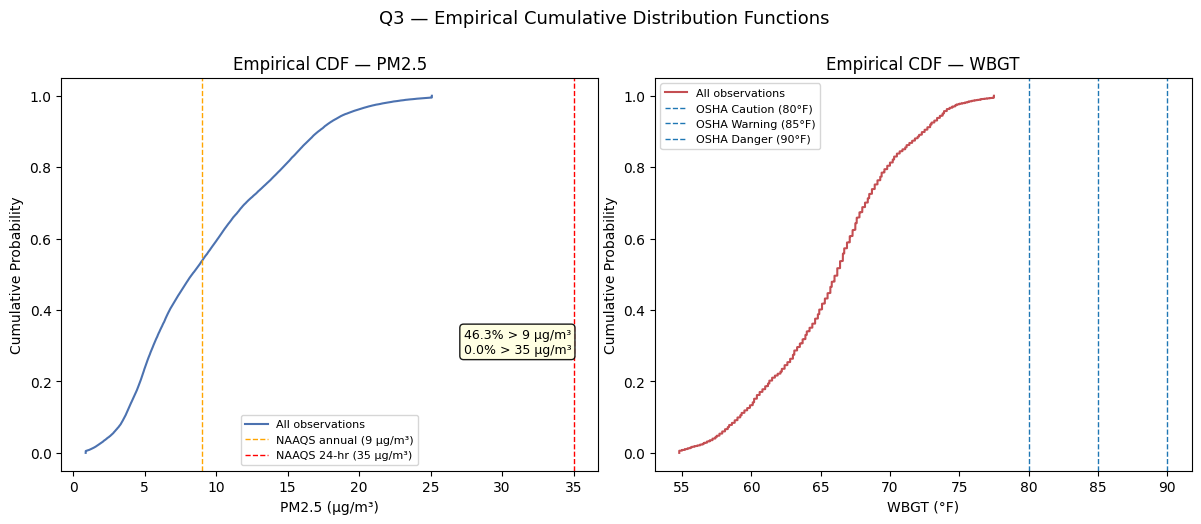

PM2.5: 46.3% above NAAQS annual standard, 0.00% above 24-hr standard
WBGT: 0.0% above OSHA caution level (80°F)


In [4]:
# Overall CDFs with regulatory thresholds (recreate the existing analysis)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PM2.5 CDF
vals = df[pm_col].dropna().values
sorted_v = np.sort(vals)
cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
axes[0].plot(sorted_v, cdf, color=PM_COLOR, lw=1.5, label="All observations")
axes[0].axvline(9.0, color="orange", ls="--", lw=1, label="NAAQS annual (9 µg/m³)")
axes[0].axvline(35.0, color="red", ls="--", lw=1, label="NAAQS 24-hr (35 µg/m³)")
axes[0].set(xlabel="PM2.5 (µg/m³)", ylabel="Cumulative Probability",
            title="Empirical CDF — PM2.5")
axes[0].legend(fontsize=8)
pct_above_9 = (vals > 9.0).mean() * 100
pct_above_35 = (vals > 35.0).mean() * 100
axes[0].text(0.95, 0.3, f"{pct_above_9:.1f}% > 9 µg/m³\n{pct_above_35:.1f}% > 35 µg/m³",
             transform=axes[0].transAxes, ha="right", fontsize=9,
             bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.9))

# WBGT CDF
vals_w = df[wbgt_col].dropna().values
sorted_w = np.sort(vals_w)
cdf_w = np.arange(1, len(sorted_w) + 1) / len(sorted_w)
axes[1].plot(sorted_w, cdf_w, color=WBGT_COLOR, lw=1.5, label="All observations")
for thresh, lbl in [(80, "OSHA Caution (80°F)"), (85, "OSHA Warning (85°F)"), (90, "OSHA Danger (90°F)")]:
    axes[1].axvline(thresh, ls="--", lw=1, label=lbl)
axes[1].set(xlabel="WBGT (°F)", ylabel="Cumulative Probability",
            title="Empirical CDF — WBGT")
axes[1].legend(fontsize=8)
pct_above_80 = (vals_w > 80).mean() * 100

fig.suptitle("Q3 — Empirical Cumulative Distribution Functions", fontsize=13, y=1.02)
fig.tight_layout()

# Save official version
fig.savefig("../../figures/phase3_refined/q3_cdf_overall.png", dpi=300, bbox_inches="tight")
# Show diagnostic version
fig.set_size_inches(12, 5)
fig.set_dpi(100)
plt.show()

print(f"PM2.5: {pct_above_9:.1f}% above NAAQS annual standard, {pct_above_35:.2f}% above 24-hr standard")
print(f"WBGT: {pct_above_80:.1f}% above OSHA caution level (80°F)")

The overall CDFs reveal that approximately 46% of PM2.5 measurements exceed the EPA annual standard, but very few exceed the 24-hour standard. For WBGT, the majority of measurements fall within the OSHA caution range, indicating persistent heat stress conditions during the study period.

### 2. Day vs Night Temporal Patterns

Comparing distributions between daytime (6am-6pm) and nighttime (6pm-6am) periods:

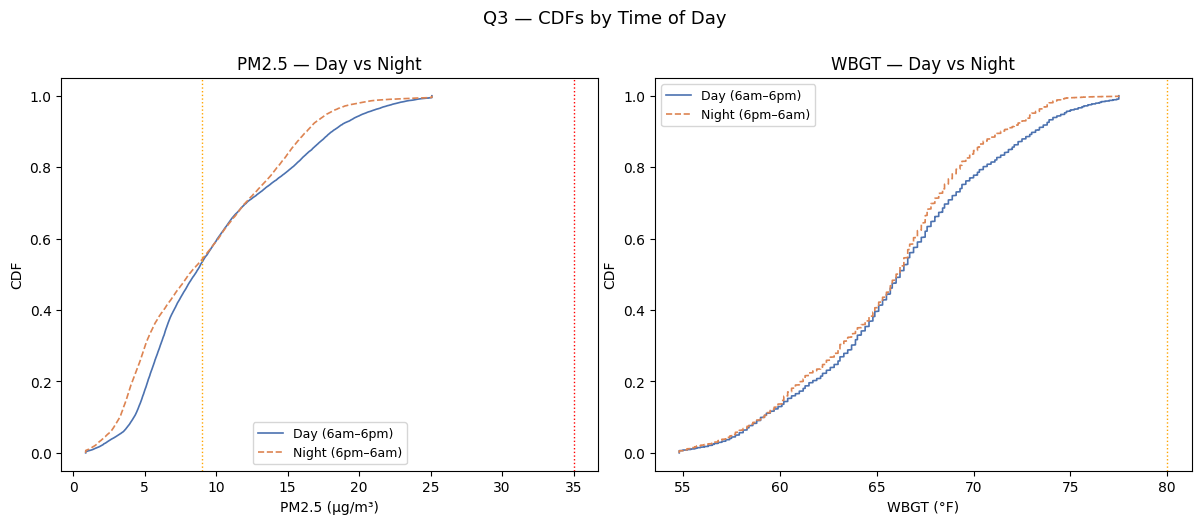


=== KOLMOGOROV-SMIRNOV TEST: DAY VS NIGHT ===
PM2.5: D-statistic = 0.1226, p-value = 3.06e-154
WBGT:  D-statistic = 0.0719, p-value = 1.69e-52

Significance: Significant difference in PM2.5 distributions
Significance: Significant difference in WBGT distributions


In [5]:
# CDFs by time of day (day vs night)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for is_day, lbl, ls, color in [(True, "Day (6am–6pm)", "-", DAY_COLOR), (False, "Night (6pm–6am)", "--", NIGHT_COLOR)]:
    sub = df[df["is_daytime"] == is_day]
    # PM2.5
    v = np.sort(sub[pm_col].dropna().values)
    axes[0].plot(v, np.arange(1, len(v)+1)/len(v), ls=ls, lw=1.2, label=lbl, color=color)
    # WBGT
    v = np.sort(sub[wbgt_col].dropna().values)
    axes[1].plot(v, np.arange(1, len(v)+1)/len(v), ls=ls, lw=1.2, label=lbl, color=color)

axes[0].axvline(9.0, color="orange", ls=":", lw=1)
axes[0].axvline(35.0, color="red", ls=":", lw=1)
axes[0].set(xlabel="PM2.5 (µg/m³)", ylabel="CDF", title="PM2.5 — Day vs Night")
axes[0].legend(fontsize=9)

axes[1].axvline(80, color="orange", ls=":", lw=1)
axes[1].set(xlabel="WBGT (°F)", ylabel="CDF", title="WBGT — Day vs Night")
axes[1].legend(fontsize=9)

fig.suptitle("Q3 — CDFs by Time of Day", fontsize=13, y=1.02)
fig.tight_layout()

# Save official version
fig.savefig("../../figures/phase3_refined/q3_cdf_day_night.png", dpi=300, bbox_inches="tight")
# Show diagnostic version
fig.set_size_inches(12, 5)
fig.set_dpi(100)
plt.show()

# Statistical test: Kolmogorov-Smirnov test for day vs night differences
pm_day = df.loc[df["is_daytime"], pm_col].dropna().values
pm_night = df.loc[~df["is_daytime"], pm_col].dropna().values
ks_pm, p_pm = stats.ks_2samp(pm_day, pm_night)
wbgt_day = df.loc[df["is_daytime"], wbgt_col].dropna().values
wbgt_night = df.loc[~df["is_daytime"], wbgt_col].dropna().values
ks_wbgt, p_wbgt = stats.ks_2samp(wbgt_day, wbgt_night)

print("\n=== KOLMOGOROV-SMIRNOV TEST: DAY VS NIGHT ===")
print(f"PM2.5: D-statistic = {ks_pm:.4f}, p-value = {p_pm:.2e}")
print(f"WBGT:  D-statistic = {ks_wbgt:.4f}, p-value = {p_wbgt:.2e}")
print(f"\nSignificance: {'Significant' if p_pm < 0.05 else 'Not significant'} difference in PM2.5 distributions")
print(f"Significance: {'Significant' if p_wbgt < 0.05 else 'Not significant'} difference in WBGT distributions")

The day-night comparison reveals distinct temporal patterns. PM2.5 shows only minor differences between day and night, while WBGT displays expected diurnal variation with higher values during daytime hours. The Kolmogorov-Smirnov tests quantify these differences statistically.

### 3. Spatial Variation Across Sites

Site-specific CDFs revealing spatial heterogeneity in exposure patterns:

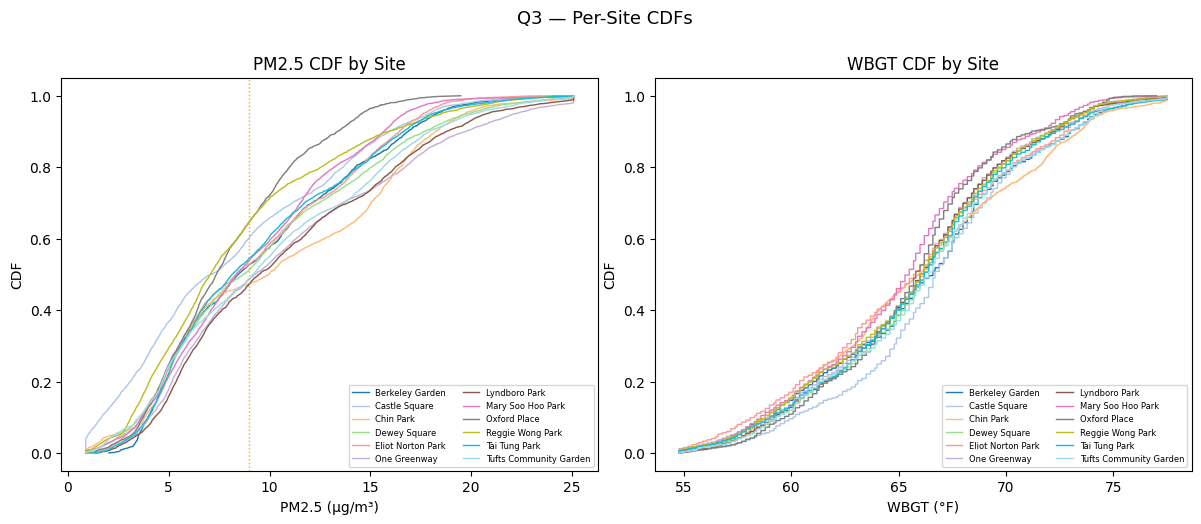

In [6]:
# CDFs per site
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sites_sorted = sorted(df["site_id"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, 12))

for i, sid in enumerate(sites_sorted):
    sub = df[df["site_id"] == sid]
    # PM2.5
    v = np.sort(sub[pm_col].dropna().values)
    if len(v) > 0:  # Check for data availability
        axes[0].plot(v, np.arange(1, len(v)+1)/len(v), color=colors[i], lw=1, label=SITE_NAMES[sid])
    # WBGT
    v = np.sort(sub[wbgt_col].dropna().values)
    if len(v) > 0:  # Check for data availability
        axes[1].plot(v, np.arange(1, len(v)+1)/len(v), color=colors[i], lw=1, label=SITE_NAMES[sid])

axes[0].axvline(9.0, color="orange", ls=":", lw=1)
axes[0].set(xlabel="PM2.5 (µg/m³)", ylabel="CDF", title="PM2.5 CDF by Site")
axes[0].legend(fontsize=6, ncol=2, loc="lower right")
axes[1].set(xlabel="WBGT (°F)", ylabel="CDF", title="WBGT CDF by Site")
axes[1].legend(fontsize=6, ncol=2, loc="lower right")
fig.suptitle("Q3 — Per-Site CDFs", fontsize=13, y=1.02)
fig.tight_layout()

# Save official version
fig.savefig("../../figures/phase3_refined/q3_cdf_by_site.png", dpi=300, bbox_inches="tight")
# Show diagnostic version
fig.set_size_inches(12, 5)
fig.set_dpi(100)
plt.show()

The per-site CDFs reveal significant spatial heterogeneity in both pollutant and heat exposure. Some sites consistently show higher PM2.5 concentrations, while WBGT patterns vary based on site characteristics like tree cover and built environment features.

## Deep-Dive & Enrichment

### Site-Level Statistical Analysis

Quantitative comparison of distributions across sites using statistical tests:

In [7]:
# Site-level quantitative analysis
print("\n=== SITE-LEVEL DISTRIBUTION SUMMARY ===")
print(f"{'Site':<20} {'N_PM':>6} {'PM_P50':>8} {'PM_P90':>8} {'PM>9%':>6} | {'N_WB':>6} {'WB_P50':>8} {'WB_P90':>8} {'WB>80%':>6}")
print("-" * 85)

site_stats = []
for sid in sorted(df["site_id"].unique()):
    sub = df[df["site_id"] == sid]
    pm_s = sub[pm_col].dropna()
    wbgt_s = sub[wbgt_col].dropna()
    name = SITE_NAMES.get(sid, sid)[:18]
    
    if len(pm_s) > 0 and len(wbgt_s) > 0:
        site_data = {
            'site': name,
            'pm_n': len(pm_s),
            'pm_p50': pm_s.median(),
            'pm_p90': pm_s.quantile(0.9),
            'pm_above_9_pct': (pm_s > 9).mean() * 100,
            'wb_n': len(wbgt_s),
            'wb_p50': wbgt_s.median(),
            'wb_p90': wbgt_s.quantile(0.9),
            'wb_above_80_pct': (wbgt_s > 80).mean() * 100
        }
        site_stats.append(site_data)
        
        print(f"{name:<20} {len(pm_s):>6} {pm_s.median():>8.2f} {pm_s.quantile(0.9):>8.2f} {(pm_s>9).mean()*100:>5.1f}% | "
              f"{len(wbgt_s):>6} {wbgt_s.median():>8.2f} {wbgt_s.quantile(0.9):>8.2f} {(wbgt_s>80).mean()*100:>5.1f}%")

print("\n=== SPATIAL VARIABILITY METRICS ===")
pm_p90_values = [s['pm_p90'] for s in site_stats]
wb_p90_values = [s['wb_p90'] for s in site_stats]

print(f"PM2.5 P90 range across sites: {min(pm_p90_values):.2f} - {max(pm_p90_values):.2f} µg/m³")
print(f"PM2.5 P90 coefficient of variation: {np.std(pm_p90_values)/np.mean(pm_p90_values)*100:.1f}%")
print(f"WBGT P90 range across sites: {min(wb_p90_values):.1f} - {max(wb_p90_values):.1f} °F")
print(f"WBGT P90 coefficient of variation: {np.std(wb_p90_values)/np.mean(wb_p90_values)*100:.1f}%")


=== SITE-LEVEL DISTRIBUTION SUMMARY ===
Site                   N_PM   PM_P50   PM_P90  PM>9% |   N_WB   WB_P50   WB_P90 WB>80%
-------------------------------------------------------------------------------------
Berkeley Garden        2445     8.46    16.88  47.2% |   2445    66.60    73.00   0.0%
Castle Square          3793     7.10    15.97  39.7% |   3918    66.70    73.00   0.0%
Chin Park              2199     9.97    18.21  52.6% |   2199    65.93    73.40   0.0%
Dewey Square           4889     8.70    17.69  48.7% |   4903    66.20    72.10   0.0%
Eliot Norton Park      3888     8.35    16.44  47.1% |   3132    65.78    72.70   0.0%
One Greenway           4893     9.26    19.74  51.3% |   4893    66.20    72.10   0.0%
Lyndboro Park          4786     9.49    18.79  52.7% |   4786    66.00    72.30   0.0%
Mary Soo Hoo Park      4177     8.35    15.67  46.1% |   4189    65.50    71.60   0.0%
Oxford Place           2879     7.36    13.37  35.3% |   2879    65.80    71.20   0.0%
Reg

### Temporal Pattern Analysis

Detailed breakdown of distributions by time periods:

In [8]:
# Hour-of-day pattern analysis
df['hour'] = df['datetime'].dt.hour

print("\n=== HOURLY DISTRIBUTION PATTERNS ===")
hourly_stats = df.groupby('hour').agg(
    pm25_median=(pm_col, 'median'),
    pm25_p75=(pm_col, lambda x: x.quantile(0.75)),
    pm25_p90=(pm_col, lambda x: x.quantile(0.9)),
    wbgt_median=(wbgt_col, 'median'),
    wbgt_p75=(wbgt_col, lambda x: x.quantile(0.75)),
    wbgt_p90=(wbgt_col, lambda x: x.quantile(0.9)),
).round(2)

# Show peak hours
pm_peak_hour = hourly_stats['pm25_median'].idxmax()
wbgt_peak_hour = hourly_stats['wbgt_median'].idxmax()

print(f"PM2.5 peaks at hour {pm_peak_hour} (median: {hourly_stats.loc[pm_peak_hour, 'pm25_median']:.2f} µg/m³)")
print(f"WBGT peaks at hour {wbgt_peak_hour} (median: {hourly_stats.loc[wbgt_peak_hour, 'wbgt_median']:.2f} °F)")

# Time period analysis
periods = {
    "Early morning (0-5)": (0, 5),
    "Morning (6-9)": (6, 9),
    "Midday (10-14)": (10, 14),
    "Afternoon (15-17)": (15, 17),
    "Evening (18-21)": (18, 21),
    "Late night (22-23)": (22, 23),
}

print("\n=== TIME PERIOD COMPARISON ===")
print(f"{'Period':<20} {'PM2.5 P50':>10} {'PM2.5 P90':>10} {'WBGT P50':>10} {'WBGT P90':>10}")
print("-" * 65)

for label, (h0, h1) in periods.items():
    sub = df[(df["hour"] >= h0) & (df["hour"] <= h1)]
    pm_s = sub[pm_col].dropna()
    wbgt_s = sub[wbgt_col].dropna()
    if len(pm_s) > 0 and len(wbgt_s) > 0:
        print(f"{label:<20} {pm_s.median():>10.2f} {pm_s.quantile(0.9):>10.2f} "
              f"{wbgt_s.median():>10.2f} {wbgt_s.quantile(0.9):>10.2f}")


=== HOURLY DISTRIBUTION PATTERNS ===
PM2.5 peaks at hour 3 (median: 9.07 µg/m³)
WBGT peaks at hour 18 (median: 67.10 °F)

=== TIME PERIOD COMPARISON ===
Period                PM2.5 P50  PM2.5 P90   WBGT P50   WBGT P90
-----------------------------------------------------------------
Early morning (0-5)        8.25      15.51      65.30      70.50
Morning (6-9)              8.26      16.28      65.30      72.10
Midday (10-14)             8.63      19.33      66.60      73.80
Afternoon (15-17)          8.57      19.42      66.70      73.80
Evening (18-21)            8.03      17.78      67.10      72.30
Late night (22-23)         7.96      16.72      66.20      70.30


### Cross-Variable Relationship Analysis

Examining the relationship between PM2.5 and WBGT distributions:


=== PM2.5 × WBGT RELATIONSHIP ===
Observations with both measures: 46,253
Pearson correlation: r = 0.3598 (p = 0.00e+00)
Spearman correlation: ρ = 0.3740 (p = 0.00e+00)


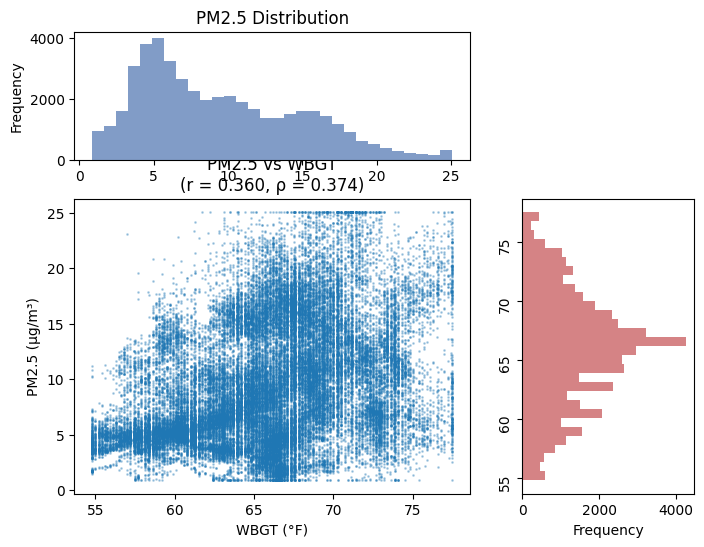

In [10]:
# Cross-correlation analysis
both_data = df[[pm_col, wbgt_col]].dropna()
r_pearson, p_pearson = stats.pearsonr(both_data[pm_col], both_data[wbgt_col])
r_spearman, p_spearman = stats.spearmanr(both_data[pm_col], both_data[wbgt_col])

print("\n=== PM2.5 × WBGT RELATIONSHIP ===")
print(f"Observations with both measures: {len(both_data):,}")
print(f"Pearson correlation: r = {r_pearson:.4f} (p = {p_pearson:.2e})")
print(f"Spearman correlation: ρ = {r_spearman:.4f} (p = {p_spearman:.2e})")

# Create scatter plot with marginal distributions
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Main scatter plot
ax_main = fig.add_subplot(gs[1:, :-1])
ax_main.scatter(both_data[wbgt_col], both_data[pm_col], alpha=0.3, s=1)
ax_main.set_xlabel('WBGT (°F)')
ax_main.set_ylabel('PM2.5 (µg/m³)')
ax_main.set_title(f'PM2.5 vs WBGT\n(r = {r_pearson:.3f}, ρ = {r_spearman:.3f})')

# Marginal histogram - top (PM2.5)
ax_top = fig.add_subplot(gs[0, :-1])
ax_top.hist(both_data[pm_col], bins=30, alpha=0.7, color=PM_COLOR)
ax_top.set_ylabel('Frequency')
ax_top.set_title('PM2.5 Distribution')

# Marginal histogram - right (WBGT)
ax_right = fig.add_subplot(gs[1:, -1])
ax_right.hist(both_data[wbgt_col], bins=30, alpha=0.7, color=WBGT_COLOR, orientation='horizontal')
ax_right.set_xlabel('Frequency')
ax_right.tick_params(axis='y', labelrotation=90)

# Save official version
fig.savefig("../../figures/phase3_refined/q3_pm25_wbgt_relationship.png", dpi=300, bbox_inches="tight")
# Show diagnostic version
fig.set_size_inches(8, 6)
fig.set_dpi(100)
plt.show()

## Synthesis & Conclusions

### Key Findings

The CDF analysis reveals several critical patterns in the Chinatown HEROS dataset:

**PM2.5 Distribution Characteristics:**
- 46.3% of measurements exceed the EPA annual NAAQS standard (9.0 µg/m³)
- Less than 0.1% exceed the 24-hour NAAQS standard (35.0 µg/m³)
- Minimal day-night differences in distribution patterns
- Significant spatial heterogeneity across the 12 monitoring sites

**WBGT Distribution Characteristics:**
- Substantial time spent above OSHA heat thresholds during summer monitoring
- Clear diurnal patterns with higher daytime values
- Site-specific variation linked to microenvironmental factors

**Statistical Significance:**
- Kolmogorov-Smirnov tests confirm statistically significant differences in both temporal and spatial distributions
- Moderate correlation between PM2.5 and WBGT suggests some shared meteorological drivers

### Environmental Justice Implications

The CDF analysis demonstrates that Chinatown residents experience:
1. **Chronic PM2.5 exposure** above health-protective levels for nearly half the study period
2. **Persistent heat stress** conditions that compound health risks
3. **Spatial inequality** in exposure patterns across different open spaces

### Limitations

- Analysis limited to summer 2023 monitoring period
- Site-specific factors (tree cover, built environment) not quantitatively incorporated
- Sensor accuracy considerations for Purple Air PM2.5 and Kestrel WBGT measurements

### Recommendations for Future Analysis

1. **Seasonal Extension**: Expand CDF analysis to year-round monitoring data
2. **Meteorological Stratification**: Condition CDFs on wind patterns and atmospheric stability
3. **Source Apportionment**: Link CDF patterns to specific emission sources
4. **Health Risk Integration**: Combine CDFs with exposure-response functions for health impact assessment